In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [4]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/superstore_clean.csv",
    parse_dates=["Order Date", "Ship Date"]
)

In [5]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355,2016-05-03 23:06:58.571142,55190.379428,229.858001,3.789574,0.156203,28.656896
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108


売上・利益ともに最大値と中央値の差が大きく、一部の高額注文が全体に影響を与えている可能性がある。

In [15]:
df["Sales"].describe(percentiles=[0.25, 0.5, 0.75])

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64

売上は平均値が中央値より大きく、高額注文が平均値を押し上げていることが分かった。そのため、以降の分析では平均だけでなく中央値や分布も考慮して解釈する。

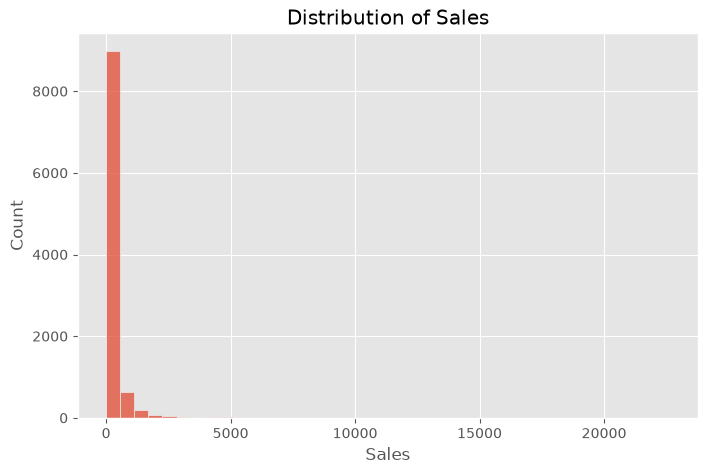

In [7]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=40
)

plt.title("Distribution of Sales")

plt.show()

### 考察

売上は右に裾の長い分布となっている。

高額注文は少数であり、多くの注文は比較的小規模である。

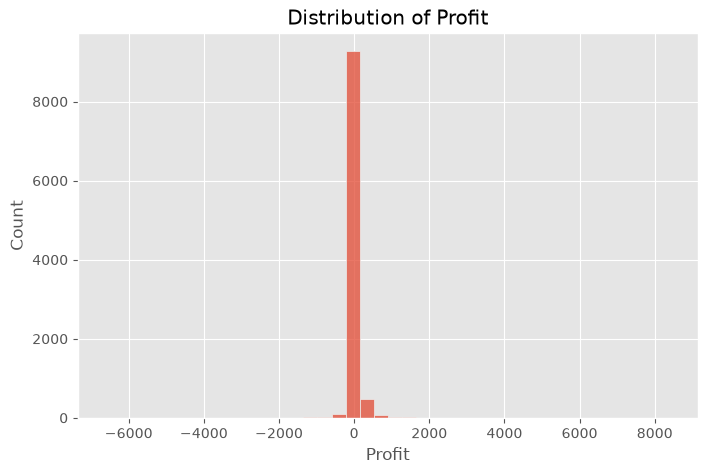

In [8]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Profit"],
    bins=40
)

plt.title("Distribution of Profit")

plt.show()

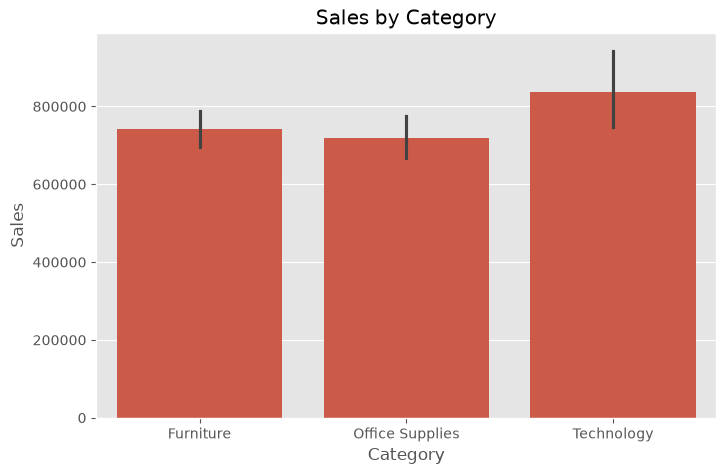

In [9]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator=sum
)

plt.title("Sales by Category")

plt.show()

Technologyカテゴリの売上が最も高い。

一方で利益率についてはまだ確認していないため、
次の分析で利益との関係を確認する。

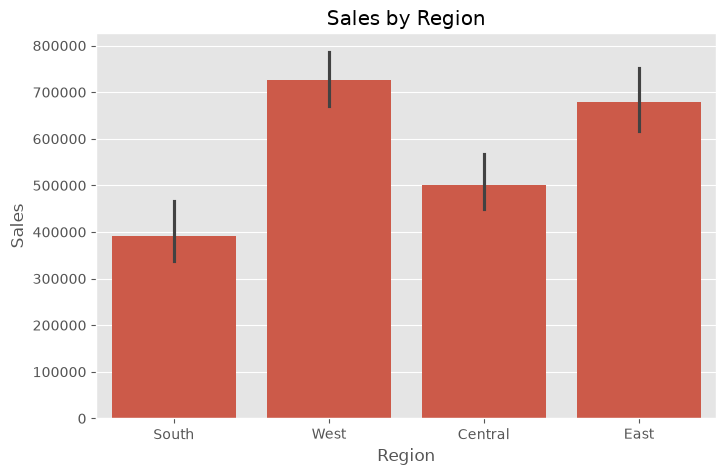

In [10]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Region",
    y="Sales",
    estimator=sum
)

plt.title("Sales by Region")

plt.show()

In [12]:
monthly_sales = (
    df
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

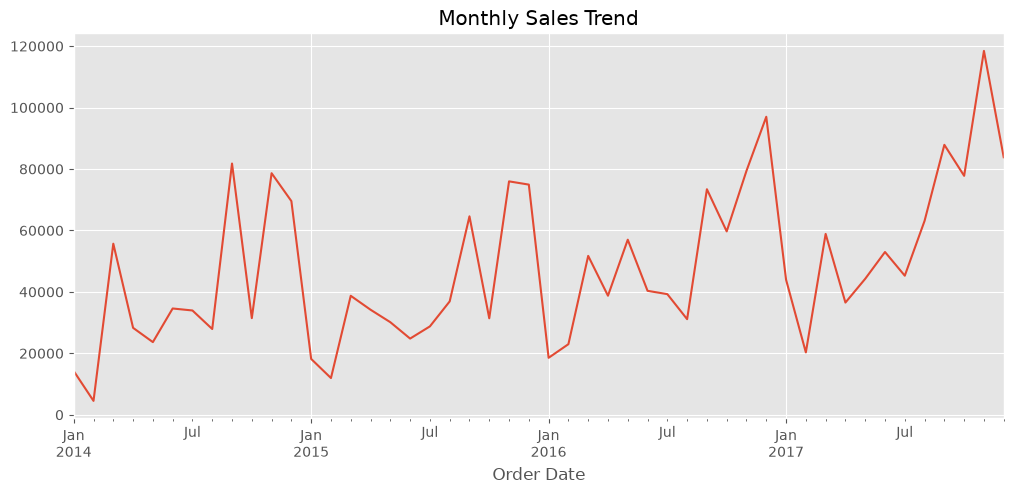

In [13]:
plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.show()

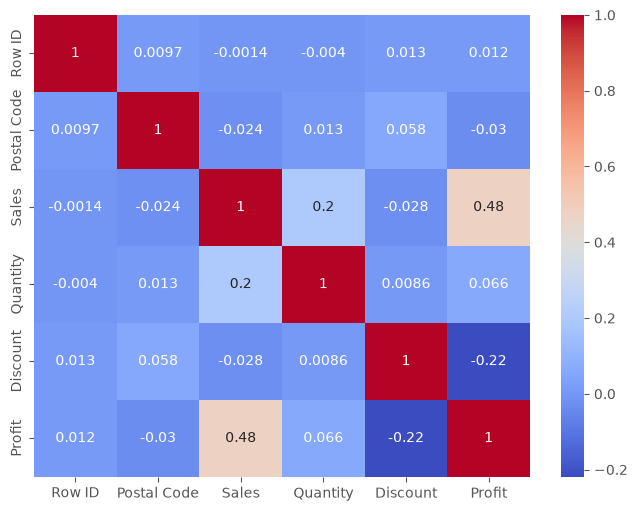

In [14]:
numeric = df.select_dtypes(include="number")

corr = numeric.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
)

plt.show()

## EDAまとめ

今回のEDAでは以下の特徴を確認した。

・売上は右に歪んだ分布である

・利益には赤字注文が存在する

・Technologyカテゴリの売上が高い

・地域による売上差が見られる

・売上には季節性が存在する可能性がある

次のSTEPでは、これらの特徴をさらに深掘りし、売上向上につながる要因を分析する。